In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import PIL.Image

# Monkey-patch PIL.Image to restore ANTIALIAS
if not hasattr(PIL.Image, 'ANTIALIAS'):
    PIL.Image.ANTIALIAS = PIL.Image.LANCZOS
    
# Now it is safe to import moviepy
from moviepy.editor import VideoFileClip
import os
from glob import glob
from pathlib import Path

In [3]:
def parse_and_bin_pbs_data(file_path, domain_size=10.0, grid_res=100):
    """
    Parses the particle-based simulation text file and bins particles into a grid.
    Handles lines starting with a time stamp.
    """
    with open(file_path, 'r') as f:
        raw_lines = f.readlines()

    times = []
    cdc42t_grids = [] 
    cdc42dm_grids = []
    cdc42dc_grids = []
    cdc42t_coords = [] 
    cdc42dm_coords = []
    cdc42dc_coords = []
    
    # Define bin edges for histogram
    bins = np.linspace(0, domain_size, grid_res + 1)
    
    i = 0
    while i < len(raw_lines):
        line = raw_lines[i].strip()
        
        # Skip empty lines
        if not line:
            i += 1
            continue
            
        # 1. Parse Time from the block header (or the first line of the block)
        try:
            # We assume the first number on the line is the time
            line_data = np.fromstring(line, sep=' ')
            current_time = line_data[0]
            times.append(current_time)
        except (ValueError, IndexError):
            i += 1
            continue
            
        # 2. Parse Cdc42T (This is the current line 'i')
        # We need to process the current line as U, because the structure 
        # implies the time is the start of the species line.
        cdc42t_line = raw_lines[i].strip()
        cdc42t_grid, cdc42t_coord = process_species_line(cdc42t_line, bins, grid_res)
            
        # 3. Parse Cdc42Dm
        # Check if i+1 exists
        if i + 1 < len(raw_lines):
            cdc42dm_line = raw_lines[i + 1].strip()
            cdc42dm_grid, cdc42dm_coord = process_species_line(cdc42dm_line, bins, grid_res)
        else:
            cdc42dm_grid = np.zeros((grid_res, grid_res))

        # 3. Parse Cdc42Dc
        # Check if i+2 exists
        if i + 2 < len(raw_lines):
            cdc42dc_line = raw_lines[i + 2].strip()
            cdc42dc_grid, cdc42dc_coord = process_species_line(cdc42dc_line, bins, grid_res)
        else:
            cdc42dc_grid = np.zeros((grid_res, grid_res))

        cdc42t_grids.append(cdc42t_grid)
        cdc42dm_grids.append(cdc42dm_grid)
        cdc42dc_grids.append(cdc42dc_grid)
        cdc42t_coords.append(cdc42t_coord)
        cdc42dm_coords.append(cdc42dm_coord)
        cdc42dc_coords.append(cdc42dc_coord)
        
        # Move to the next time block. 
        # There are 3 species lines per time step.
        i += 3 

    # Stack into (Time, Height, Width, Channels)
    u_array = np.stack([cdc42t_grids, cdc42dm_grids, cdc42dc_grids], axis=-1)
    u_coords = np.stack([cdc42t_coords, cdc42dm_coords, cdc42dc_coords], axis=-1)
    
    return u_array, u_coords, np.array(times)

def process_species_line(line, bins, grid_res):
    """
    Parses one line into coordinates and a binned grid.
    """
    if not line or line.strip() == '0':
        return np.zeros((grid_res, grid_res)), np.zeros((0, 2))
    
    data = np.fromstring(line, sep=' ')
    if data.size <= 1:
        return np.zeros((grid_res, grid_res)), np.zeros((0, 2))
    
    # Drop leading time stamp if odd number of values
    coords_flat = data[1:] if data.size % 2 != 0 else data
        
    try:
        coords = coords_flat.reshape(-1, 2)
        grid, _, _ = np.histogram2d(coords[:, 0], coords[:, 1], bins=[bins, bins])
        return grid.T, coords 
    except ValueError:
        return np.zeros((grid_res, grid_res)), np.zeros((0, 2))

def parse_and_bin_pbs_data(file_path, domain_size=10.0, grid_res=100):
    with open(file_path, 'r') as f:
        raw_lines = f.readlines()

    times = []
    cdc42t_grids, cdc42dm_grids, cdc42dc_grids = [], [], []
    cdc42t_coords, cdc42dm_coords, cdc42dc_coords = [], [], []
    
    bins = np.linspace(0, domain_size, grid_res + 1)
    
    i = 0
    while i < len(raw_lines):
        line = raw_lines[i].strip()
        if not line:
            i += 1
            continue
            
        try:
            line_data = np.fromstring(line, sep=' ')
            times.append(line_data[0])
        except (ValueError, IndexError):
            i += 1
            continue
            
        # Parse the 3 species lines
        g1, c1 = process_species_line(raw_lines[i].strip(), bins, grid_res)
        g2, c2 = process_species_line(raw_lines[i+1].strip() if i+1 < len(raw_lines) else "", bins, grid_res)
        g3, c3 = process_species_line(raw_lines[i+2].strip() if i+2 < len(raw_lines) else "", bins, grid_res)

        cdc42t_grids.append(g1); cdc42t_coords.append(c1)
        cdc42dm_grids.append(g2); cdc42dm_coords.append(c2)
        cdc42dc_grids.append(g3); cdc42dc_coords.append(c3)
        
        i += 3 

    # Synchronize lengths
    n_f = min(len(times), len(cdc42t_grids))
    u_array = np.stack([cdc42t_grids[:n_f], cdc42dm_grids[:n_f], cdc42dc_grids[:n_f]], axis=-1)
    
    # Coordinates MUST stay as a list of lists because N varies per frame
    u_coords = [cdc42t_coords[:n_f], cdc42dm_coords[:n_f], cdc42dc_coords[:n_f]]
    
    return u_array, u_coords, np.array(times[:n_f])

def animate_uarray(u_array, u_coords, times, domain_size, name=None, titles=("Cdc42T", "Cdc42Dm", "Cdc42Dc")):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Column-specific color limits for density
    vmaxs = [u_array[:,:,:,k].max() if u_array[:,:,:,k].max() > 0 else 1 for k in range(3)]

    scats = []
    imshs = []

    for k in range(3):
        # Top Row: Scatter
        axes[0, k].set_xlim(0, domain_size)
        axes[0, k].set_ylim(0, domain_size)
        axes[0, k].set_aspect('equal')
        axes[0, k].set_title(f"{titles[k]} Particles")
        # Initialize scatter with first frame
        pts = u_coords[k][0]
        scat = axes[0, k].scatter(pts[:, 0], pts[:, 1], s=1, alpha=0.5, c='C0')
        scats.append(scat)

        # Bottom Row: Density
        axes[1, k].set_title(f"{titles[k]} Density")
        im = axes[1, k].imshow(u_array[0, :, :, k], cmap='viridis', vmin=0, vmax=vmaxs[k], origin='lower', extent=[0, domain_size, 0, domain_size])
        fig.colorbar(im, ax=axes[1, k], fraction=0.046, pad=0.04)
        imshs.append(im)

    main_title = fig.suptitle(f'T = {times[0]:.2f}', fontsize=16)

    def animate(frame):
        for k in range(3):
            # Update Scatter: use set_offsets for scatter plots
            pts = u_coords[k][frame]
            scats[k].set_offsets(pts if pts.size > 0 else np.zeros((0, 2)))
            
            # Update Density
            imshs[k].set_array(u_array[frame, :, :, k])
            
        # Update the text artist
        main_title.set_text(f'T = {times[frame]:.2f}')
        return scats + imshs + [main_title]

    anim = animation.FuncAnimation(fig, animate, frames=len(times), interval=100, blit=False)
    
    if name:
        writergif = animation.PillowWriter(fps=10)
        anim.save(f'{name}.gif', writer=writergif)
    
    return anim

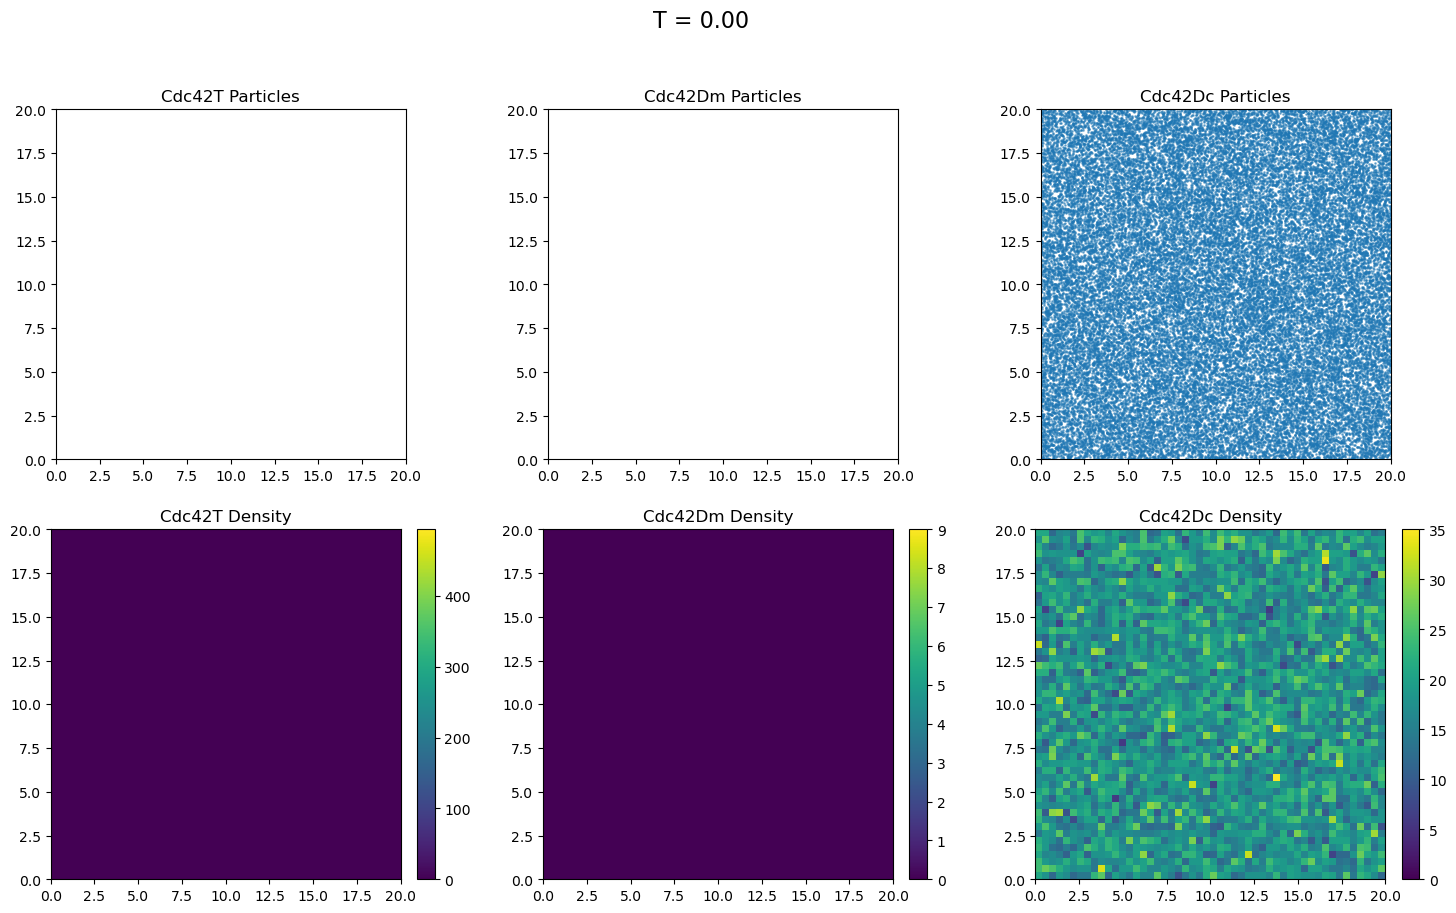

In [10]:
sim_path = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/modules/pbs/runs/second_go/length_30_scale_3-seeds_1.xyz'
path_obj = Path(sim_path)
parent_dir = path_obj.parent.name
file_stem = path_obj.stem
save_path = f"gifs/{parent_dir}_{file_stem}"

u_array, u_coords, times = parse_and_bin_pbs_data(sim_path, domain_size=20, grid_res=50)
animate_uarray(u_array, u_coords, times, domain_size=20, name=save_path, titles=("Cdc42T", "Cdc42Dm", "Cdc42Dc"))

In [5]:
def convert_avi_to_gif(source_dir, target_fps=10, resize_factor=None):
    """
    Converts all .avi files in source_dir to .gif.
    
    Args:
        source_dir (str): Path to directory containing .avi files.
        target_fps (int): Frames per second for the GIF (lower = smaller file).
        resize_factor (float): 0.5 resizes video to 50% (helps reduce GIF size).
    """
    # Find all .avi files and create outdir
    avi_files = glob(os.path.join(source_dir, "*.avi"))
    outdir = os.path.join(source_dir, 'gif')
    os.mkdir(outdir)
    
    if not avi_files:
        print("No .avi files found in the directory.")
        return

    print(f"Found {len(avi_files)} files. Starting conversion...")

    for video_path in avi_files:
        try:
            # Construct output filename
            filename = os.path.basename(video_path)
            gif_name = os.path.splitext(filename)[0] + ".gif"
            output_path = os.path.join(outdir, gif_name)
            
            print(f"Converting {filename}...")
            
            # Load and convert
            with VideoFileClip(video_path) as clip:
                # Resize if requested (e.g., to reduce file size)
                if resize_factor:
                    clip = clip.resize(resize_factor)
                
                clip.write_gif(output_path, fps=target_fps, verbose=False, logger=None)
                
        except Exception as e:
            print(f"Failed to convert {video_path}: {e}")

    print("Batch conversion complete.")

# --- Usage ---
# convert_avi_to_gif('/path/to/your/avi_files', target_fps=15, resize_factor=0.5)

In [7]:
avi_path = '/work/users/s/m/smyersn/elston/projects/multiple_polarity_sites/simulations/pbs/variable_size/2D_combined_polarity_circuit/movies'
convert_avi_to_gif(avi_path, target_fps=15, resize_factor=1)

Found 38 files. Starting conversion...
Converting length_10-seeds_1.avi...
Converting length_10-seeds_10.avi...
Converting length_10-seeds_2.avi...
Converting length_10-seeds_3.avi...
Converting length_10-seeds_4.avi...
Converting length_10-seeds_5.avi...
Converting length_10-seeds_6.avi...
Converting length_10-seeds_7.avi...
Converting length_10-seeds_8.avi...
Converting length_10-seeds_9.avi...
Converting length_15-seeds_1.avi...
Converting length_15-seeds_10.avi...
Converting length_15-seeds_2.avi...
Converting length_15-seeds_3.avi...
Converting length_15-seeds_4.avi...
Converting length_15-seeds_5.avi...
Converting length_15-seeds_6.avi...
Converting length_15-seeds_7.avi...
Converting length_15-seeds_8.avi...
Converting length_15-seeds_9.avi...
Converting length_20-seeds_1.avi...
Converting length_20-seeds_2.avi...
Converting length_20-seeds_3.avi...
Converting length_20-seeds_5.avi...
Converting length_20-seeds_6.avi...
Converting length_20-seeds_8.avi...
Converting length_20-se